<a href="https://colab.research.google.com/github/Bhupinder-2004/FCC_projects/blob/main/sea_level_predictor_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

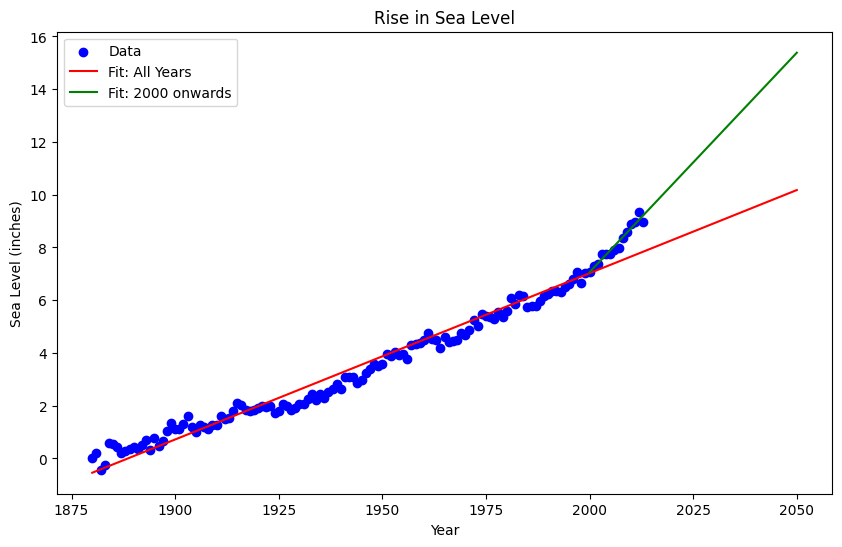

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def draw_plot():

    df = pd.read_csv("epa-sea-level.csv", skiprows=4)

    df.columns = ['Year', 'CSIRO Adjusted Sea Level', 'Lower Error Bound', 'Upper Error Bound', 'NOAA Adjusted Sea Level']

    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df['CSIRO Adjusted Sea Level'] = pd.to_numeric(df['CSIRO Adjusted Sea Level'], errors='coerce')

    df.dropna(subset=['Year', 'CSIRO Adjusted Sea Level'], inplace=True)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'], color='blue', label='Data')

    slope_all, intercept_all, _, _, _ = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
    years_all = list(range(int(df['Year'].min()), 2051))
    sea_level_all = [intercept_all + slope_all * x for x in years_all]
    ax.plot(years_all, sea_level_all, 'r', label='Fit: All Years')

    df_recent = df[df['Year'] >= 2000]
    slope_recent, intercept_recent, _, _, _ = linregress(df_recent['Year'], df_recent['CSIRO Adjusted Sea Level'])
    years_recent = list(range(2000, 2051))
    sea_level_recent = [intercept_recent + slope_recent * x for x in years_recent]
    ax.plot(years_recent, sea_level_recent, 'green', label='Fit: 2000 onwards')

    ax.set_xlabel("Year")
    ax.set_ylabel("Sea Level (inches)")
    ax.set_title("Rise in Sea Level")
    ax.legend()

    fig.savefig('sea_level_plot.png')

    return fig

if __name__ == "__main__":
    draw_plot()
    plt.show()